### DEAM dataset - Database for Emotional Analysis of Music
[DEAM - Kaggle](https://www.kaggle.com/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music)\
[DEAM - Université de Genève](https://cvml.unige.ch/databases/DEAM/)

Prepare data

In [1]:
# import sys
# import os

# # sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "src")))
# sys.path.append(os.path.abspath(os.path.join("../src")))

# from audio_processing import (
#     load_mean_valence_arousal,
#     load_valence_arousal,
#     get_song_ids_and_labels,
#     DEAMSegmentGenerator,
# )

# print(load_mean_valence_arousal(os.path.abspath(os.path.join("../data/"))))

In [2]:
# print(load_valence_arousal(os.path.abspath(os.path.join("../data/"))))

In [3]:
# print(load_valence_arousal(os.path.abspath(os.path.join("../data/")), span=2))

Właściwe przygotowanie danych

In [4]:
# import tensorflow as tf

# print(tf.config.list_physical_devices("GPU"))

In [5]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, False)
        tf.config.set_logical_device_configuration(
            gpus[0],
            [
                tf.config.LogicalDeviceConfiguration(memory_limit=4000)
            ],  # Limit to 4000 MB of VRAM (for my 3050 Ti laptop GPU)
        )
    except RuntimeError as e:
        print(e)

2026-05-08 11:01:42.316842: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 11:01:42.327415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778230902.339623   26295 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778230902.343617   26295 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778230902.353297   26295 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [6]:
import sys
import os
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(os.path.join("../src")))
from model import MER_CNN_Model, MER_CNN_Simple, MER_CNN_VGG_Style, MER_CRNN, MER_CNN_MobileNet
from audio_processing import DEAMSegmentGenerator, preprocess_deam, load_valence_arousal, get_song_ids_and_labels

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [7]:
# PARAMETRY GLOBALNE - MUSZĄ BYĆ SPÓJNE W CAŁYM PROJEKCIE
SR = 22050  # Domyślna częstotliwość librosa.load
HOP_LENGTH = 512  # Krok przesunięcia okna FFT
SEGMENT_WIDTH = 128  # Szerokość obrazka wejściowego do sieci (oś czasu)
N_MELS = 128  # Wysokość obrazka wejściowego do sieci (oś częstotliwości)
SPAN = 3.0  # Jak bardzo uśredniamy etykiety w DataFrame (w sekundach)
DEAM_DIR = os.path.abspath(os.path.join("../data/"))
AUDIO_DIR = os.path.abspath(os.path.join("../data/DEAM/MEMD_audio/"))
AUDIO_NPY_DIR = os.path.abspath(os.path.join("../data/DEAM/audio_npy/"))

In [8]:
labels_df = load_valence_arousal(DEAM_DIR, span=SPAN)
dynamic_labels = get_song_ids_and_labels(labels_df)

In [9]:
# Run only once to preprocess audio files into Mel spectrograms and save as .npy
# preprocess_deam(AUDIO_DIR, AUDIO_NPY_DIR, n_mels=N_MELS, hop_length=HOP_LENGTH, sr=SR)

In [10]:
existing_song_ids = [
    s_id for s_id in dynamic_labels.keys() if os.path.exists(os.path.join(AUDIO_NPY_DIR, f"{s_id}.npy"))
]

print(f"Znaleziono {len(existing_song_ids)} utworów z danymi audio i etykietami.")

Znaleziono 1744 utworów z danymi audio i etykietami.


In [11]:
train_ids, val_ids = train_test_split(existing_song_ids, test_size=0.2)
print(f"Trening na {len(train_ids)} utworach, walidacja na {len(val_ids)} utworach.")

Trening na 1395 utworach, walidacja na 349 utworach.


In [12]:
train_generator = DEAMSegmentGenerator(
    song_ids=train_ids,
    labels_dict=dynamic_labels,
    data_dir=AUDIO_NPY_DIR,
    segment_width=SEGMENT_WIDTH,
    hop_size=HOP_LENGTH,
    sr=SR,
    batch_size=32,
    shuffle=True,
)
valid_generator = DEAMSegmentGenerator(
    song_ids=val_ids,
    labels_dict=dynamic_labels,
    data_dir=AUDIO_NPY_DIR,
    segment_width=SEGMENT_WIDTH,
    hop_size=HOP_LENGTH,
    sr=SR,
    batch_size=32,
    shuffle=False,
)

In [13]:
model_CNN = MER_CNN_Simple()
model_CNN.fit(
    train_generator,
    validation_generator=valid_generator,
    epochs=50,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint("best_model.h5", save_best_only=True),
    ],
)

I0000 00:00:1778230917.806899   26295 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4000 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1778230917.830457   26295 cuda_executor.cc:479] failed to allocate 3.91GiB (4194304000 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Epoch 1/50


/home/jakseluz/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1778230920.260578   26512 service.cc:152] XLA service 0x7f31ac007530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778230920.260597   26512 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-05-08 11:02:00.341634: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778230920.681153   26512 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/544 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.1995 - mae: 0.3326

I0000 00:00:1778230925.302320   26512 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

544/544 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0199 - mae: 0.1103 - val_loss: 0.0172 - val_mae: 0.1022 - learning_rate: 1.2500e-04
Epoch 37/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0200 - mae: 0.1117 - val_loss: 0.0179 - val_mae: 0.1040 - learning_rate: 1.2500e-04
Epoch 38/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0199 - mae: 0.1105 - val_loss: 0.0196 - val_mae: 0.1088 - learning_rate: 1.2500e-04
Epoch 39/50
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0195 - mae: 0.1099

544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0195 - mae: 0.1099 - val_loss: 0.0167 - val_mae: 0.1021 - learning_rate: 1.2500e-04
Epoch 40/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0194 - mae: 0.1091

544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0194 - mae: 0.1091 - val_loss: 0.0164 - val_mae: 0.1001 - learning_rate: 1.2500e-04
Epoch 41/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0191 - mae: 0.1086 - val_loss: 0.0169 - val_mae: 0.1015 - learning_rate: 1.2500e-04
Epoch 42/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0190 - mae: 0.1086 - val_loss: 0.0167 - val_mae: 0.1022 - learning_rate: 1.2500e-04
Epoch 43/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0193 - mae: 0.1094

544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0193 - mae: 0.1094 - val_loss: 0.0161 - val_mae: 0.0989 - learning_rate: 1.2500e-04
Epoch 44/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 0.0190 - mae: 0.1081 - val_loss: 0.0279 - val_mae: 0.1311 - learning_rate: 1.2500e-04
Epoch 45/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0187 - mae: 0.1074 - val_loss: 0.0172 - val_mae: 0.1032 - learning_rate: 1.2500e-04
Epoch 46/50
542/544 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0183 - mae: 0.1062

544/544 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0183 - mae: 0.1063 - val_loss: 0.0147 - val_mae: 0.0946 - learning_rate: 1.2500e-04
Epoch 47/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0181 - mae: 0.1057 - val_loss: 0.0163 - val_mae: 0.0994 - learning_rate: 1.2500e-04
Epoch 48/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0184 - mae: 0.1065 - val_loss: 0.0148 - val_mae: 0.0949 - learning_rate: 1.2500e-04
Epoch 49/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0182 - mae: 0.1061 - val_loss: 0.0162 - val_mae: 0.0992 - learning_rate: 1.2500e-04
Epoch 50/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0183 - mae: 0.1061 - val_loss: 0.0152 - val_mae: 0.0969 - learning_rate: 1.2500e-04


In [14]:
from datetime import datetime
import pickle
import glob


def save_model(model, save_path, history, name=""):
    save_dir = "{}/".format(save_path)
    os.makedirs(save_dir, exist_ok=True)

    file_details = (
        f"{model.__class__.__name__}_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}_{name if name else ''}.h5"
    )
    model_path = os.path.join(save_dir, file_details)
    model.save(model_path)
    print(f"Model saved to: {model_path}")
    if history is not None:
        pickle.dump(history, open(f"{save_dir}/history_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl", "wb"))


def load_model(model_path, history):
    model_files = glob.glob(model_path + "/*.h5")
    latest_model_file = max(model_files, key=os.path.getctime)
    model = tf.keras.models.load_model(latest_model_file)
    history_files = glob.glob(model_path + "/history*.pkl")
    latest_history_file = max(history_files, key=os.path.getctime) if history_files else None
    history = pickle.load(open(latest_history_file, "rb")) if history else None
    return model, history

In [17]:
save_model(model_CNN._model, "models/MER_CNN_Simple/", history=model_CNN._model.history, name="MER_CNN_Simple")

Model saved to: models/MER_CNN_Simple//Sequential_2026-05-08_11-15-16_MER_CNN_Simple.h5


In [18]:
model123, history123 = load_model("models/MER_CNN_Simple/", history=True)

/home/jakseluz/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [19]:
import matplotlib.pyplot as plt


def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Wykres straty (Loss - MSE)
    ax[0].plot(history.history["loss"], label="Train Loss")
    ax[0].plot(history.history["val_loss"], label="Val Loss")
    ax[0].set_title("Model Loss (MSE)")
    ax[0].legend()

    # Wykres błędu (MAE)
    ax[1].plot(history.history["mae"], label="Train MAE")
    ax[1].plot(history.history["val_mae"], label="Val MAE")
    ax[1].set_title("Model Metric (MAE)")
    ax[1].legend()

    plt.show()

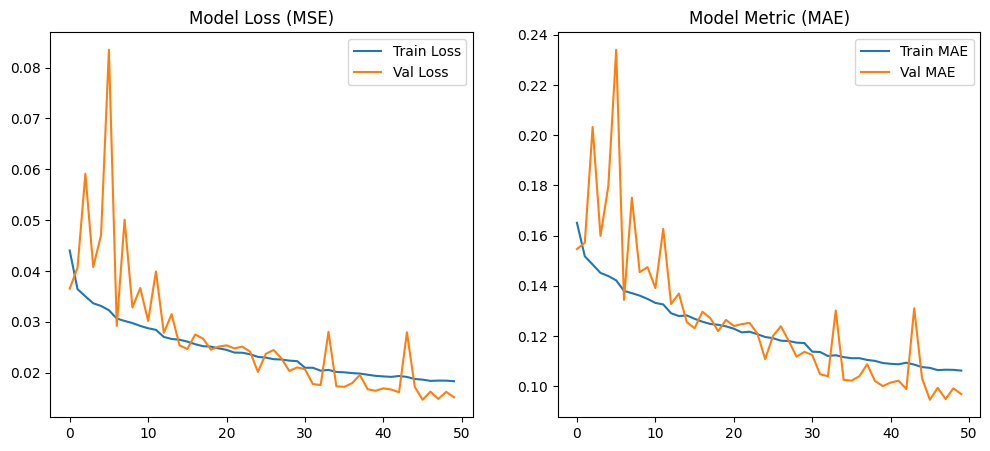

In [20]:
plot_history(history123)

In [ ]:
def plot_va_scatter(y_true, y_pred):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true[:, 0], y_true[:, 1], alpha=0.3, label="Prawdziwe", color="blue")
    plt.scatter(y_pred[:, 0], y_pred[:, 1], alpha=0.3, label="Przewidziane", color="red")

    # Rysowanie osi V-A
    plt.axhline(0, color="black", lw=1)
    plt.axvline(0, color="black", lw=1)

    plt.xlabel("Valence")
    plt.ylabel("Arousal")
    plt.title("Rozkład przewidywań w przestrzeni V-A")
    plt.legend()
    plt.show()

544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


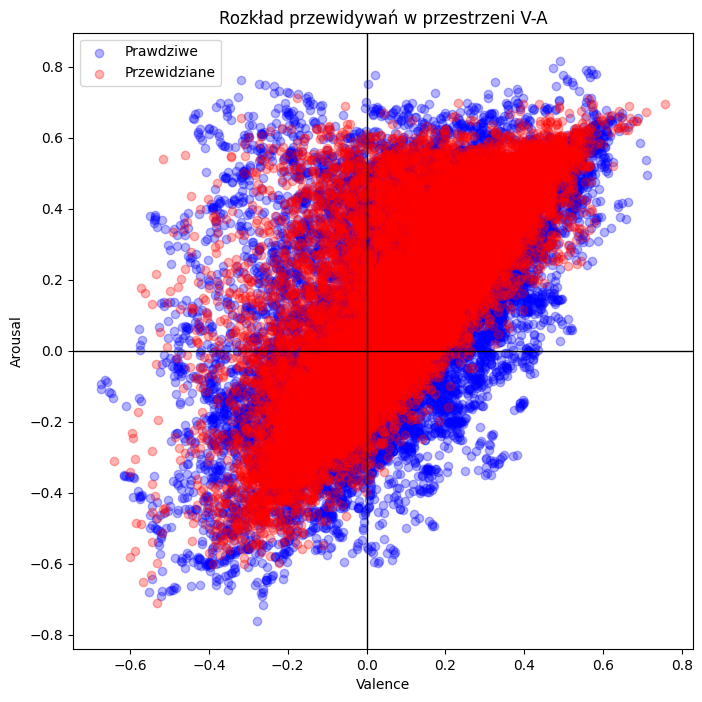

In [23]:
import numpy as np

valid_generator.shuffle = False
valid_generator.on_epoch_end()  # resetujemy kolejność próbek

y_pred = model_CNN.predict(valid_generator)


def get_y_true(generator):
    y_true = []

    # Iterujemy tylko po pełnych batchach (tyle samo, ile widzi model.predict)
    num_batches = len(generator)
    for i in range(num_batches):
        # Pobieramy batch danych (X, y)
        _, y_batch = generator[i]
        y_true.extend(y_batch)

    return np.array(y_true)


y_true = get_y_true(valid_generator)
y_pred = model_CNN.predict(valid_generator)
plot_va_scatter(y_true, y_pred)

In [26]:
from tensorflow.keras.models import Model


def visualize_feature_maps(model, sample_spectrogram, layer_name):
    # Tworzymy model pośredni, który kończy się na wybranej warstwie
    intermediate_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    feature_maps = intermediate_model.predict(sample_spectrogram[np.newaxis, ...])

    # Wyświetlamy np. pierwsze 8 filtrów
    num_filters = 8
    fig, axes = plt.subplots(1, num_filters, figsize=(20, 5))
    for i in range(num_filters):
        axes[i].imshow(feature_maps[0, :, :, i], cmap="viridis")
        axes[i].axis("off")
    plt.show()


import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def visualize_feature_maps(model, sample_spectrogram, layer_name):
    # 1. Znajdujemy indeks warstwy o danej nazwie
    layer_idx = None
    for i, layer in enumerate(model.layers):
        if layer.name == layer_name:
            layer_idx = i
            break

    if layer_idx is None:
        print(f"Błąd: Nie znaleziono warstwy o nazwie '{layer_name}'.")
        print("Dostępne warstwy:", [l.name for l in model.layers])
        return

    # 2. Tworzymy nowy model Sequential, który zawiera warstwy od 0 do layer_idx
    # To omija błąd AttributeError: sequential has never been called
    intermediate_model = tf.keras.Sequential(model.layers[: layer_idx + 1])

    # 3. Przygotowujemy dane (dodajemy wymiar batcha: (1, 128, 128, 1))
    input_data = sample_spectrogram[np.newaxis, ...]

    # 4. Przewidujemy wynik dla tej warstwy
    feature_maps = intermediate_model.predict(input_data)

    # 5. Wizualizacja (np. pierwsze 8 filtrów)
    num_filters = min(8, feature_maps.shape[-1])
    fig, axes = plt.subplots(1, num_filters, figsize=(20, 5))

    if num_filters == 1:
        axes = [axes]  # obsługa przypadku z jednym filtrem

    for i in range(num_filters):
        # Wyświetlamy mapę cech (feature map)
        axes[i].imshow(feature_maps[0, :, :, i], cmap="viridis")
        axes[i].set_title(f"Filtr {i}")
        axes[i].axis("off")

    plt.suptitle(f"Mapy cech dla warstwy: {layer_name}")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


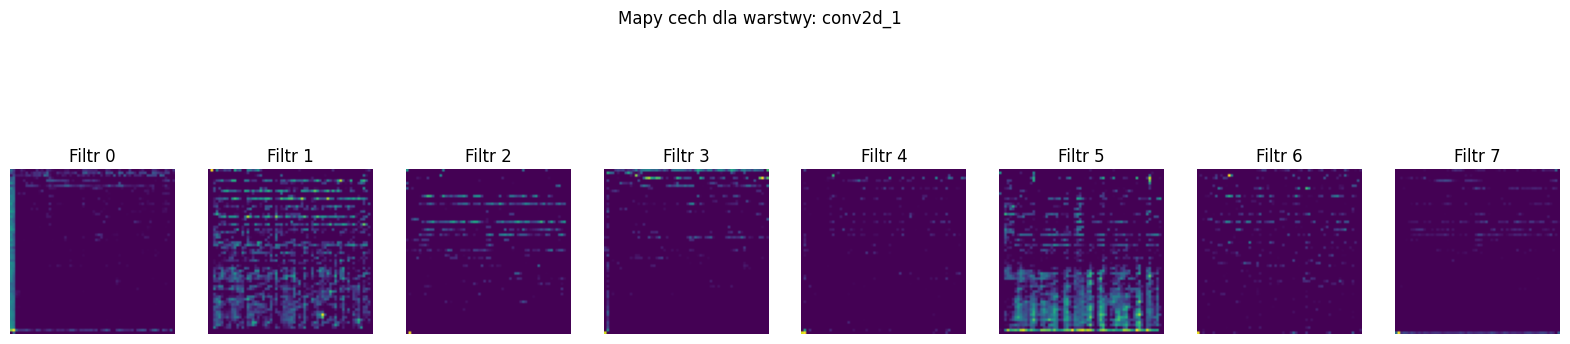

In [27]:
visualize_feature_maps(model_CNN._model, valid_generator[0][0][0], layer_name="conv2d_1")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


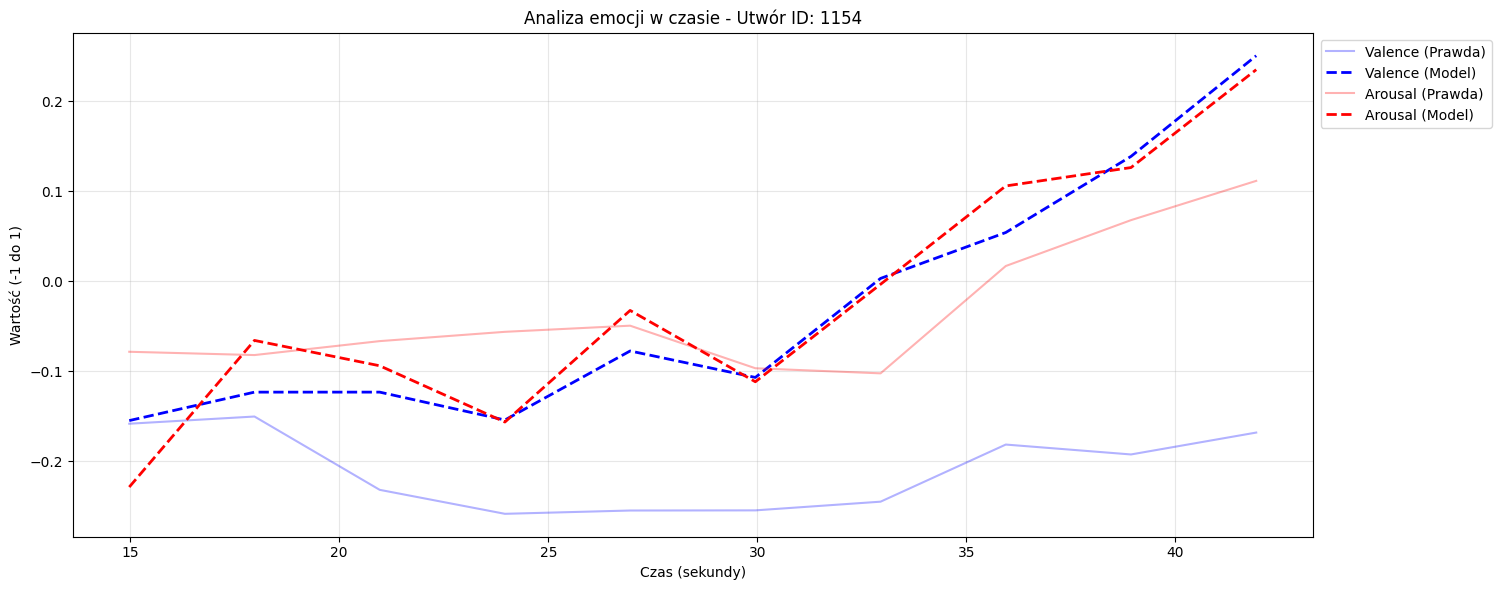

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os


def plot_song_evolution(model, generator, song_id):
    song_id = str(song_id)

    # 1. Znajdź wszystkie próbki dla tej piosenki i POSORTUJ je chronologicznie
    # Musimy to posortować, bo generator robi shuffle!
    song_samples = [s for s in generator.samples if s[0] == song_id]
    song_samples.sort(key=lambda x: x[1])  # sortowanie po start_frame

    if not song_samples:
        print(f"Błąd: Nie znaleziono próbek dla piosenki {song_id} w tym generatorze.")
        return

    X_song = []
    y_true_song = []
    timestamps = []

    # 2. Załaduj spektrogram całego utworu raz (oszczędność czasu)
    file_path = os.path.join(generator.data_dir, f"{song_id}.npy")
    full_spec = np.load(file_path, mmap_mode="r")

    # 3. Pobierz segmenty i etykiety
    for _, start_frame in song_samples:
        # Wycinek audio
        segment = full_spec[:, start_frame : start_frame + generator.segment_width]
        X_song.append(segment)

        # Przelicz klatkę na sekundy dla osi X
        time_sec = (start_frame * generator.hop_size) / generator.sr
        timestamps.append(time_sec)

        # Pobierz etykietę (znajdź najbliższą czasowo w słowniku)
        time_ms = int(time_sec * 1000)
        available_times = list(generator.labels[song_id].keys())
        closest_time = min(available_times, key=lambda x: abs(x - time_ms))
        y_true_song.append(generator.labels[song_id][closest_time])

    # 4. Predykcja modelu (cała piosenka na raz)
    X_song = np.array(X_song)[..., np.newaxis]
    y_pred_song = model.predict(X_song)
    y_true_song = np.array(y_true_song)

    # 5. Rysowanie wykresu
    plt.figure(figsize=(15, 6))

    # Valence
    plt.plot(timestamps, y_true_song[:, 0], "b-", alpha=0.3, label="Valence (Prawda)")
    plt.plot(timestamps, y_pred_song[:, 0], "b--", lw=2, label="Valence (Model)")

    # Arousal
    plt.plot(timestamps, y_true_song[:, 1], "r-", alpha=0.3, label="Arousal (Prawda)")
    plt.plot(timestamps, y_pred_song[:, 1], "r--", lw=2, label="Arousal (Model)")

    plt.title(f"Analiza emocji w czasie - Utwór ID: {song_id}")
    plt.xlabel("Czas (sekundy)")
    plt.ylabel("Wartość (-1 do 1)")
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# PRZYKŁAD UŻYCIA:
# Wybierz ID piosenki z tych, które są w Twoim zbiorze walidacyjnym
random_song_id = val_ids[0]
plot_song_evolution(model_CNN._model, valid_generator, random_song_id)